---
title: Working with Sentinel-2 in Julia SentinelDataSource.jl package
subtitle: Direct access to analysis-ready data cubes
authors:
  - name: Felix Cremer
    orcid: 
    github: felixcremer
    affiliations:
      - id: Max Planck Institute for Biogeochemistry
        institution: Max Planck Institute for Biogeochemistry
        ror: 
date: 2026-01-16
thumbnail: ../static/ESA_EOPF_logo_2025_COLOR_ESA_blue_reduced.png
keywords: ["data access", "julia", "EOPF Zarr products"]
tags: ["sentinel-2", "julia-eopf", "land"]
releaseDate: 2025-05-19
datePublished: 2025-05-19
dateModified: 2025-11-25
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

```{image} ../static/EOPF-on-bright-baseline.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```

## Table of Contents
1. [Introduction](#Introduction_XEOPF)
2. [Install the SentinelDataSource package](#Install_XEOPF)
3. [Import modules](#Import_XEOPF)
4. [Main Features of the SentinelDataSource package](#Main_Features_XEOPF)
5. [Open the Product in Native Mode](#Native_XEOPF)
6. [Conclusion](#Conclusion_XEOPF)

(Introduction_XEOPF)=
## Introduction

**SentinelDataSource.jl** is a Julia package that extends **DimensionalData** to load EOPF Zarr data. This backend enables **seamless access to ESA EOPF data products** stored in the **Zarr** format, presenting them as analysis-ready data structures.

This notebook demonstrates how to use the **SentinelDataSource** package to explore and analyze EOPF Zarr datasets. It highlights the key features currently supported.

- 🐙 **GitHub:** [JuliaGeo SentinelDataSource](https://github.com/JuliaGeo/SentinelDataSource.jl)  
- ❗ **Issue Tracker:** [Submit or view issues](https://github.com/JuliaGeo/SentinelDataSource.jl/issues) 

:::{hint} Overview
**Questions**
- How do I install the SentinelDataSource package?
- How can I use the SentinelDataSource package effectively?
- What features does the SentinelDataSource package provide?

**Objectives**
- Learn how to open EOPF Zarr products.
- Understand the key features and capabilities of the SentinelDataSource package.
:::

---

(Install_XEOPF)=
## Install the SentinelDataSource package

The SentinelDataSource package can be installed as any Julia package via the internal package manager.

```julia
] add https://github.com/JuliaGeo/SentinelDataSource.jl.git
``` 

---

(Import_XEOPF)=
## Import Package

The SentinelDataSource package is the library to open EOPF datasets. This is integrated into the DimensionalData ecosystem and the JuliaGeo ecosystem.


In [1]:
using SentinelDataSource
using YAXArrays

---

(Main_Features_XEOPF)=
## Main Features of the SentinelDataSource package

The SentinelDataSource package will at the moment open the EOPF datasets in **Native Mode** and will return a DimTree of the data.

---

## Open the Product in Native Mode

### Sentinel-2 Level-2A

We begin with a simple example by accessing a Sentinel-2 L2A product in native mode. To obtain the product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-2-l2a/items/S2B_MSIL2A_20250518T112119_N0511_R037_T29RLL_20250518T140519?.language=en&.asset=asset-product) to locate a tile and retrieve the URL from the **"EOPF Product"** asset.

In [2]:
path = joinpath(
    "https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:notebook-data/tutorial_data/",
    "cpm_v262/S2A_MSIL2A_20200707T101031_N0500_R022_T32TPS_20230614T182201.zarr"
)

"https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:notebook-data/tutorial_data/cpm_v262/S2A_MSIL2A_20200707T101031_N0500_R022_T32TPS_20230614T182201.zarr"

We can use `SentinelDataSource.open_datatree` to open the EOPF Zarr product as an `DimensionalData.DimTree`.

In [3]:
dt = SentinelDataSource.open_tree(path)

┌ DimTree ┐
├ branches ┤
  :measurements
    └─ :reflectance
        ├─ :r20m dims: X, Y size: 5490×5490 layers: :b12, :b11, :b07, :b04, :b01, :b02, :b03, :b8a, :b06, :b05
        ├─ :r60m dims: X, Y size: 1830×1830 layers: :b12, :b11, :b07, :b09, :b04, :b01, :b02, :b03, :b06, :b8a, :b05
        └─ :r10m dims: X, Y size: 10980×10980 layers: :b02, :b03, :b08, :b04
  :conditions
    ├─ :mask
    │    ├─ :detector_footprint
    │    │    ├─ :r20m dims: X, Y size: 5490×5490 layers: :b8a, :b06, :b12, :b11, :b07, :b05
    │    │    ├─ :r60m dims: X, Y size: 1830×1830 layers: :b10, :b01, :b09
    │    │    └─ :r10m dims: X, Y size: 10980×10980 layers: :b02, :b03, :b08, :b04
    │    ├─ :l1c_classification
    │    │    └─ :r60m dims: X, Y size: 1830×1830 layers: :b00
    │    └─ :l2a_classification
    │        ├─ :r20m dims: X, Y size: 5490×5490 layers: :scl
    │        └─ :r60m dims: X, Y size: 1830×1830 layers: :scl
    ├─ :geometry                      dims: X, Y, angle, Band, detector s

As an example, we plot the 60 meters red band to view the image. 

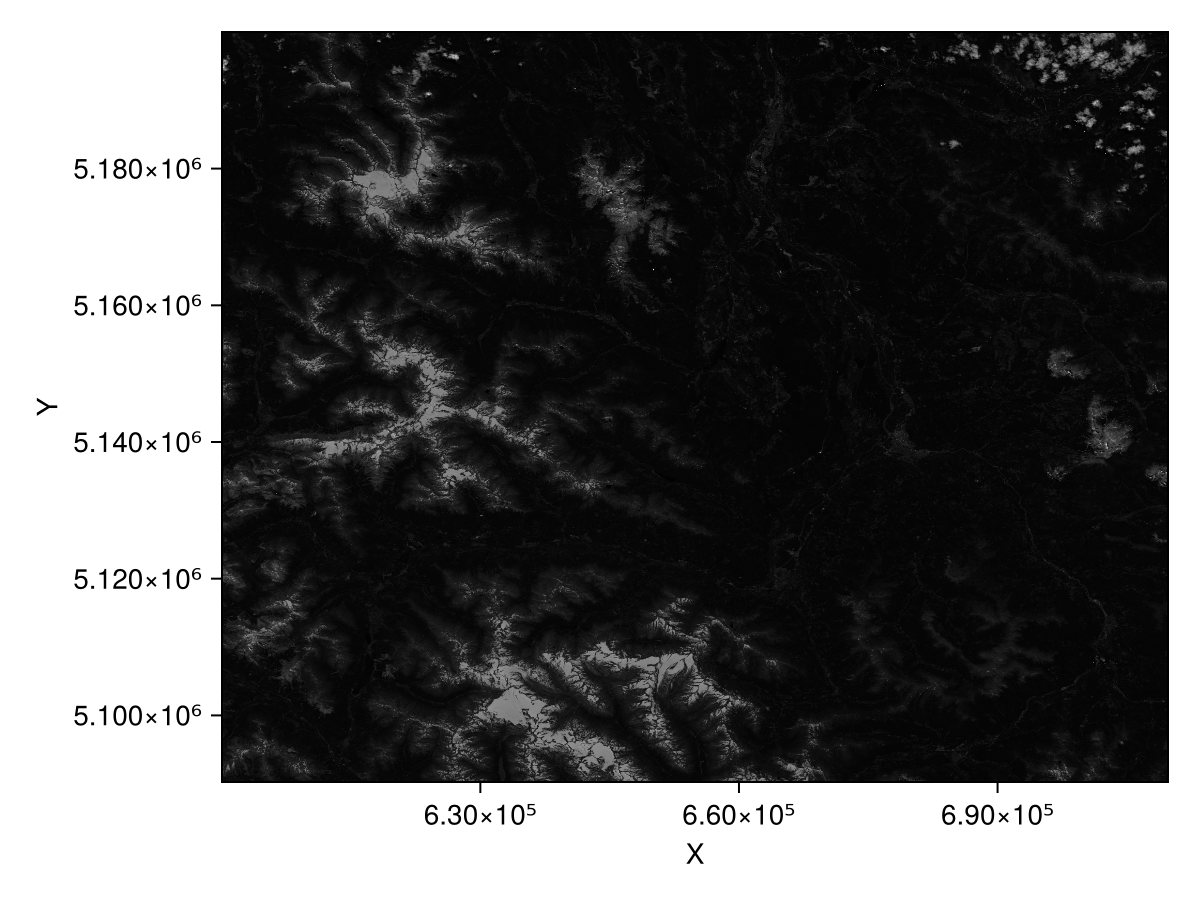

In [4]:
using CairoMakie
data = dt.measurements.reflectance.r60m[:b04]
fig, ax, h = image(data)


---

(Conclusion_XEOPF)=
## Conclusion

This notebook presents the current development state of the **SentinelDataSource.jl** package, which enables seamless access to EOPF Zarr products in the familiar DimensionalData ecosystem.
The key takeaways are summarized below:

  - EOPF products are opened without modification using DimensionalData `DimTree` and structures.  
  - These DimTree objects can be queried with the selectors as other DimensionalData objects. 
  
### Future Development Steps

* Incorporate user feedback—please test the plugin and submit issues here: https://github.com/JuliaGeo/SentinelDataSource.jl/issues

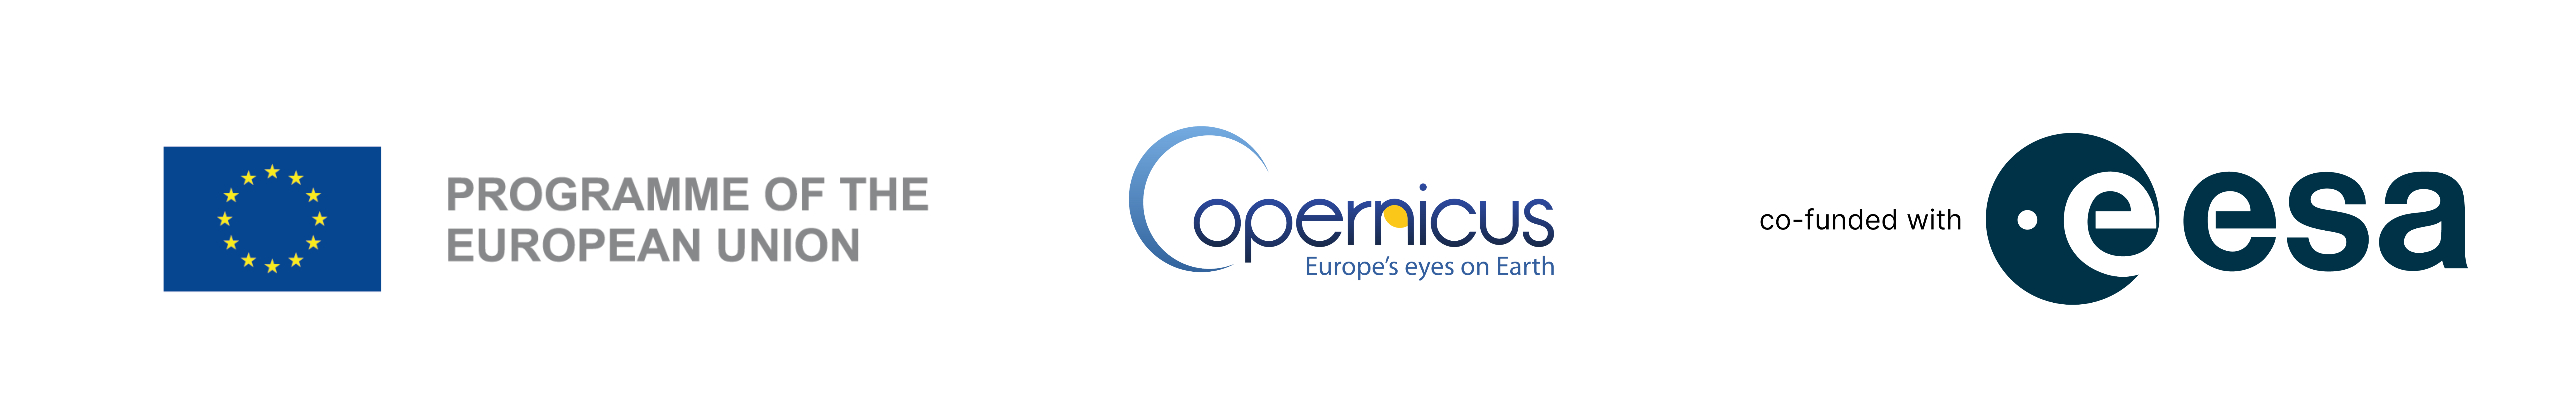